# 2025 CITS4012 Individual Assignment
*Make sure you change the file name with your student id.*

# Readme


# 1.Dataset Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [1]:
# Import to Google Drive (Enter resource location)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -U "numpy==1.26.4" "scipy==1.11.4" "gensim==4.3.2" "smart-open<7.0" "wrapt==1.15.0" #Features that may need to be installed in the new environment

In [3]:
# Data manipulation and utilities
import pandas as pd
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Tools for deep learning models
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

# Dimensionality reduction for visualization
from sklearn.manifold import TSNE

# Evaluation metrics for classification
from sklearn.metrics import accuracy_score, f1_score

# Interactive UI components (for Colab/Jupyter)
import ipywidgets as widgets
from IPython.display import display

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
# Load the training set, test set, and label textt
train_df = pd.read_csv('drive/MyDrive/Individual Assignment DATASET/medical_tc_train.csv')
test_df = pd.read_csv('drive/MyDrive/Individual Assignment DATASET/medical_tc_test.csv')
labels_df = pd.read_csv('drive/MyDrive/Individual Assignment DATASET/medical_tc_labels.csv')

In [5]:
# Build an English stopword set for filtering common words
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                          # convert to string and lowercase
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)          # keep only letters and spaces
    toks = word_tokenize(text)                        # tokenize into words
    toks = [w for w in toks if w not in stop_words and len(w) > 1]    # remove stopwords and single-character tokens
    return " ".join(toks)                             # join back to a cleaned string

# Apply the cleaning function to all abstracts in training and test sets
train_texts_cleaned = [clean_text(t) for t in train_df['medical_abstract']]
test_texts_cleaned  = [clean_text(t) for t in test_df['medical_abstract']]


In [6]:
# Tokenize each cleaned training text into a list of words
train_tokens = [word_tokenize(txt) for txt in train_texts_cleaned]

# Initialize a Keras Tokenizer and build the vocabulary from training texts
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_texts_cleaned)

# Extract the word-to-index mapping and vocabulary size
word_index = tokenizer.word_index
vocab_size = len(word_index)

# Convert training and test texts into sequences of integer indices
train_sequences = tokenizer.texts_to_sequences(train_texts_cleaned)
test_sequences  = tokenizer.texts_to_sequences(test_texts_cleaned)

# Compute sequence lengths and set max_len as the 90th percentile
lengths  = [len(seq) for seq in train_sequences]
max_len  = int(np.percentile(lengths, 90))

# Pad or truncate all sequences to the same length (post-padding with zeros)
train_padded = pad_sequences(train_sequences, maxlen=max_len, padding='post')
test_padded  = pad_sequences(test_sequences,  maxlen=max_len, padding='post')

# Prepare labels: shift from 1-based to 0-based indexing
y_train = train_df['condition_label'].values - 1
y_test  = test_df['condition_label'].values - 1

In [7]:
# Output Log
def token_log_min(train_sequences, test_sequences, train_padded, test_padded, max_len, vocab_size, y_train=None, y_test=None):
    import numpy as np
    Ltr = np.array([len(s) for s in train_sequences]); Lte = np.array([len(s) for s in test_sequences])
    trunc_tr = (Ltr > max_len).mean(); trunc_te = (Lte > max_len).mean()
    pad_tr = (max_len - np.minimum(Ltr, max_len)).mean()
    pad_te = (max_len - np.minimum(Lte, max_len)).mean()
    print(f"[VOCAB] size={vocab_size}")
    print(f"[LEN] max_len={max_len} | train mean={Ltr.mean():.1f} p90={np.percentile(Ltr,90):.0f} trunc={trunc_tr:.1%} | test mean={Lte.mean():.1f} trunc={trunc_te:.1%}")
    print(f"[PAD] avg_pad train={pad_tr:.1f} | test={pad_te:.1f}")
    print(f"[SEQ] train={train_padded.shape} | test={test_padded.shape}" + (f" | classes={len(set(y_train))}" if y_train is not None else ""))

token_log_min(train_sequences, test_sequences, train_padded, test_padded, max_len, vocab_size, y_train, y_test)

[VOCAB] size=32303
[LEN] max_len=166 | train mean=108.9 p90=166 trunc=9.6% | test mean=108.1 trunc=9.7%
[PAD] avg_pad train=59.7 | test=60.4
[SEQ] train=(11550, 166) | test=(2888, 166) | classes=5


Interim Conclusions：

I reduce the cutoff from the 95th percentile to the 90th percentile, effectively improving operational efficiency and reducing redundant data.

1.The corpus provides comprehensive coverage.(32303)

2.max_len=166 represents a prudent trade-off between performance and information retention (compared to p95); it offers controllable truncation ratios, minimal padding, and is shielded by masking.


# 2.Word Embedding Construction
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [8]:
embed_dim = 200  # dimensionality of the word vectors
w2v_model = Word2Vec(sentences=train_tokens, vector_size=embed_dim, window=5, min_count=1, sg=1, workers=4, epochs=5)
# Basic Parameters for Word Vector Training

In [9]:
# Path to the pre-trained BioWordVec (word2vec binary format)
bio_model_path = 'drive/MyDrive/Individual Assignment DATASET/bio_embedding_extrinsic'

# Load pre-trained vectors into a Gensim KeyedVectors instance
bio_wv = KeyedVectors.load_word2vec_format(bio_model_path, binary=True)

# Initialize embedding matrices
embedding_matrix_w2v = np.zeros((vocab_size + 1, embed_dim))
embedding_matrix_bio = np.zeros((vocab_size + 1, embed_dim))

# Fill each row i with the vector of word whose index is i
for word, idx in word_index.items():

    # Self-trained Word2Vec: use the trained vector if present; otherwise random init
    if word in w2v_model.wv:
        embedding_matrix_w2v[idx] = w2v_model.wv[word]
    else:
        embedding_matrix_w2v[idx] = np.random.normal(scale=0.6, size=(embed_dim,))

    # Pre-trained BioWordVec: use the pre-trained vector if present; otherwise random init
    if word in bio_wv:
        embedding_matrix_bio[idx] = bio_wv[word]
    else:
        embedding_matrix_bio[idx] = np.random.normal(scale=0.6, size=(embed_dim,))

In [10]:
# Output Log
def embed_brief_log(word_index, w2v_model, bio_wv, M_w2v, M_bio, embed_dim):
    import numpy as np
    vocab_size = len(word_index)
    w2v_dim = getattr(getattr(w2v_model, "wv", w2v_model), "vector_size", None)
    bio_dim = getattr(bio_wv, "vector_size", None)
    warn = " [WARN dim mismatch]" if (w2v_dim and w2v_dim!=embed_dim) or (bio_dim and bio_dim!=embed_dim) else ""
    print(f"[EMBED] dim={embed_dim} vocab={vocab_size} w2v_dim={w2v_dim} bio_dim={bio_dim}{warn}")

    w2v_keys = getattr(getattr(w2v_model, "wv", w2v_model), "key_to_index", {})
    bio_keys = getattr(bio_wv, "key_to_index", {})
    cov_w2v = sum(1 for w in word_index if w in w2v_keys)
    cov_bio = sum(1 for w in word_index if w in bio_keys)
    pct = lambda x: 100.0 * x / max(vocab_size, 1)
    print(f"[COVER] W2V {cov_w2v}/{vocab_size} ({pct(cov_w2v):.1f}%) | BIO {cov_bio}/{vocab_size} ({pct(cov_bio):.1f}%)")

    def mline(name, M):
        rn = np.linalg.norm(M, axis=1)
        print(f"[{name}] shape={M.shape} pad0={np.allclose(M[0],0)} rn_mu={rn.mean():.3f} rn_sd={rn.std():.3f}")
    mline("W2V_MAT", M_w2v)
    mline("BIO_MAT", M_bio)

embed_brief_log(word_index, w2v_model, bio_wv, embedding_matrix_w2v, embedding_matrix_bio, embed_dim)

[EMBED] dim=200 vocab=32303 w2v_dim=200 bio_dim=200
[COVER] W2V 32303/32303 (100.0%) | BIO 31890/32303 (98.7%)
[W2V_MAT] shape=(32304, 200) pad0=True rn_mu=1.570 rn_sd=0.915
[BIO_MAT] shape=(32304, 200) pad0=True rn_mu=4.547 rn_sd=0.732


Interim Conclusions：

1.Both vector sets share the same dimension (200 dimensions), with a vocabulary size of 32,303 and coverage rates of 100% and 98.7%, respectively, sufficient to support subsequent comparisons.

2.Padding is not included in the calculation.

3.The pre-trained vectors exhibit larger and more stable row norms, while the self-trained vectors are more dispersed.

# 3.Visualization
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

Visual Terms List: ['aspirin', 'diabetes', 'cancer', 'fever', 'infection', 'pain', 'blood', 'heart', 'kidney', 'brain']
Use t-SNE perplexity = 5 , Number of samples = 10


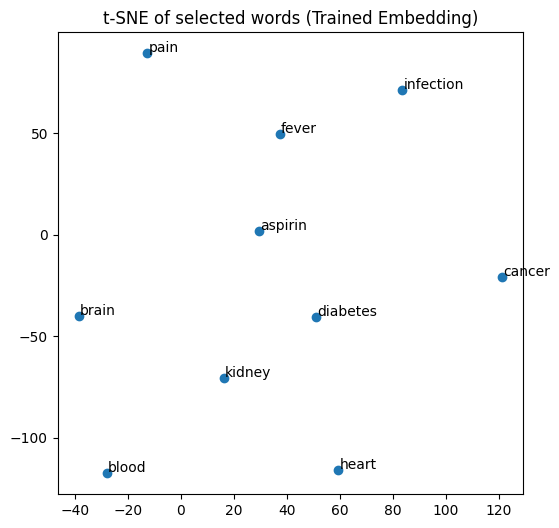

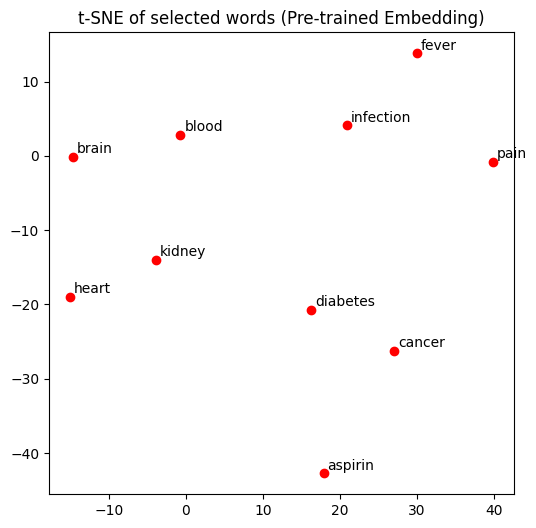

In [11]:
# Define the candidate medical terms to visualize
terms = ["aspirin", "diabetes", "cancer", "fever", "infection", "pain", "blood", "heart", "kidney", "brain"]

# Keep only words that exist in: (1) Keras tokenizer vocab, (2) our trained Word2Vec, and (3) the pre-trained BioWordVec
terms_in_vocab = [t for t in terms if t in word_index and t in w2v_model.wv and t in bio_wv]
print("Visual Terms List:", terms_in_vocab)

# Check sample size and set a safe perplexity for t-SNE (must be < n)
n = len(terms_in_vocab)
if n < 3:
    print("The visual samples are too few (<3). Please try again with a different set of common words.")
else:
    # Perplexity: between 2 and 5, but strictly less than n (use n-1 as an upper bound)
    perp = max(2, min(5, n - 1))
    print("Use t-SNE perplexity =", perp, ", Number of samples =", n)

    # ---------- Trained Word2Vec ----------
    # Stack vectors (n, embed_dim) from our trained model
    vectors_w2v = np.array([w2v_model.wv[t] for t in terms_in_vocab])

    # Configure t-SNE to 2D with a fixed random seed for reproducibility
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=1000)

    # Project high-dimensional vectors into 2D
    vecs_w2v_2d = tsne.fit_transform(vectors_w2v)

    # Plot the 2D embedding with annotations
    plt.figure(figsize=(6, 6))
    plt.scatter(vecs_w2v_2d[:, 0], vecs_w2v_2d[:, 1])
    for i, word in enumerate(terms_in_vocab):
        # Slight offset to reduce overlap between point and label
        plt.annotate(word, (vecs_w2v_2d[i, 0] + 0.5, vecs_w2v_2d[i, 1] + 0.5))
    plt.title("t-SNE of selected words (Trained Embedding)")
    plt.show()

    # ---------- Pre-trained BioWordVec ----------
    # Stack vectors (n, embed_dim) from the pre-trained biomedical embeddings
    vectors_bio = np.array([bio_wv[t] for t in terms_in_vocab])

    # Another t-SNE run (do not reuse the fitted model above)
    tsne2 = TSNE(n_components=2, random_state=42, perplexity=perp, max_iter=1000)
    vecs_bio_2d = tsne2.fit_transform(vectors_bio)

    # Plot the 2D embedding with annotations
    plt.figure(figsize=(6, 6))
    plt.scatter(vecs_bio_2d[:, 0], vecs_bio_2d[:, 1], c='red')
    for i, word in enumerate(terms_in_vocab):
        plt.annotate(word, (vecs_bio_2d[i, 0] + 0.5, vecs_bio_2d[i, 1] + 0.5))
    plt.title("t-SNE of selected words (Pre-trained Embedding)")
    plt.show()

Interim Conclusions：

1.Compared to self-trained vectors (left), pre-trained vectors (right) exhibit more reasonable medical semantic proximity relationships and more compact local structures.

2.The self-trained vector distribution is more dispersed. Under identical t-distribution parameters, BioWordVec demonstrates superior preservation of clinical semantic structure.

# 4.RNN-based Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [12]:
# Model using self-trained Word2Vec embeddings
model_w2v = Sequential([
    # initialize with self-trained Word2Vec
    Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        weights=[embedding_matrix_w2v],
        trainable=True,
        mask_zero=True
    ),
    # LSTM initialize
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    # Output layer
    Dense(len(labels_df), activation='softmax')
])

# Compile with sparse labels, Adam optimizer, accuracy metric
model_w2v.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Model using pre-trained BioWordVec embeddings
model_bio = Sequential([
    Embedding(
        input_dim=vocab_size + 1,
        output_dim=embed_dim,
        weights=[embedding_matrix_bio],
        trainable=True,
        mask_zero=True
    ),
    # LSTM initialize
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(len(labels_df), activation='softmax')
])

# Compile with sparse labels, Adam optimizer, accuracy metric
model_bio.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [13]:
# Output Log
def model_minilog(model, name, sample_batch):
    emb = next(l for l in model.layers if isinstance(l, Embedding))
    dense = next(l for l in model.layers if isinstance(l, Dense))
    W = emb.get_weights()[0]; pad0 = np.allclose(W[0], 0)
    x = tf.convert_to_tensor(sample_batch[:2]); y = model(x)
    print(f"[{name}] params={model.count_params():,} EMB={W.shape} mask={emb.mask_zero} pad0={pad0} OUT={dense.units} IO={x.shape}->{y.shape}")

model_minilog(model_w2v, "W2V", train_padded)
model_minilog(model_bio, "BIO", train_padded)

[W2V] params=6,629,893 EMB=(32304, 200) mask=True pad0=True OUT=5 IO=(2, 166)->(2, 5)
[BIO] params=6,629,893 EMB=(32304, 200) mask=True pad0=True OUT=5 IO=(2, 166)->(2, 5)


Interim Conclusions：

Both models have correct structures and mask settings, the model will automatically ignore padding and not treat it as a word. Input and output dimensions must match, and parameter scales are consistent.

In [14]:
# Number of epochs for classifier training
epochs = 25

# Train the model with self-trained Word2Vec embeddings
history_w2v = model_w2v.fit(train_padded, y_train, epochs=epochs, batch_size=32, validation_split=0.1, verbose=1)

# Train the model with pre-trained Word2Vec embeddings
history_bio = model_bio.fit(train_padded, y_train, epochs=epochs, batch_size=32, validation_split=0.1, verbose=1)

# Display model architectures and parameter counts
model_w2v.summary()
model_bio.summary()

Epoch 1/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 194s 578ms/step - accuracy: 0.4677 - loss: 1.2647 - val_accuracy: 0.5463 - val_loss: 1.0586
Epoch 2/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 186s 574ms/step - accuracy: 0.5915 - loss: 0.9870 - val_accuracy: 0.5732 - val_loss: 1.0303
Epoch 3/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 205s 584ms/step - accuracy: 0.6676 - loss: 0.8389 - val_accuracy: 0.5628 - val_loss: 1.0296
Epoch 4/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 202s 584ms/step - accuracy: 0.7118 - loss: 0.7030 - val_accuracy: 0.5489 - val_loss: 1.0636
Epoch 5/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 198s 571ms/step - accuracy: 0.7395 - loss: 0.6109 - val_accuracy: 0.5368 - val_loss: 1.1256
Epoch 6/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 202s 571ms/step - accuracy: 0.7744 - loss: 0.5207 - val_accuracy: 0.5299 - val_loss: 1.2074
Epoch 7/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 189s 583ms/step - accuracy: 0.7868 - loss: 0.4565 - val_accuracy: 0.5134 - val_loss: 1.3314
Epoch 8/25
325/325 ━━━━━━━━━━━━━━━━━━━━ 201s 580ms/step - accuracy: 0.7896 -

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (2, 166, 200)          │     6,460,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (2, 128)               │       168,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (2, 5)                 │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,889,681 (75.87 MB)

 Trainable params: 6,629,893 (25.29 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (2, 166, 200)          │     6,460,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (2, 128)               │       168,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (2, 5)                 │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,889,681 (75.87 MB)

 Trainable params: 6,629,893 (25.29 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 13,259,788 (50.58 MB)

Interim Conclusions：

Both models peaked early on, followed by a sustained decline in validation performance, indicating significant overfitting; Bio showed a slight edge over W2V in its initial peak.

# 5.Performance Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [18]:
# Predict class probabilities for the test set using self-trained embedding model
y_pred_w2v = model_w2v.predict(test_padded)
# Convert probability distributions into predicted class indices
y_pred_labels_w2v = y_pred_w2v.argmax(axis=1)

# Predict with the BioWordVec embedding model
y_pred_bio = model_bio.predict(test_padded)
y_pred_labels_bio = y_pred_bio.argmax(axis=1)

# Evaluate performance: Accuracy and Macro-F1 for self-trained model
acc_w2v = accuracy_score(y_test, y_pred_labels_w2v)
f1_w2v = f1_score(y_test, y_pred_labels_w2v, average='macro')

# Evaluate performance: Accuracy and Macro-F1 for pre-trained model
acc_bio = accuracy_score(y_test, y_pred_labels_bio)
f1_bio = f1_score(y_test, y_pred_labels_bio, average='macro')

# Print results for comparison
print(f"Model1 (Self-trained)  Accuracy = {acc_w2v:.4f}, Macro F1 = {f1_w2v:.4f}")
print(f"Model2 (Pre-trained)   Accuracy = {acc_bio:.4f}, Macro F1 = {f1_bio:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step
Model1 (Self-trained)  Accuracy = 0.4401, Macro F1 = 0.4421
Model2 (Pre-trained)   Accuracy = 0.4640, Macro F1 = 0.4569


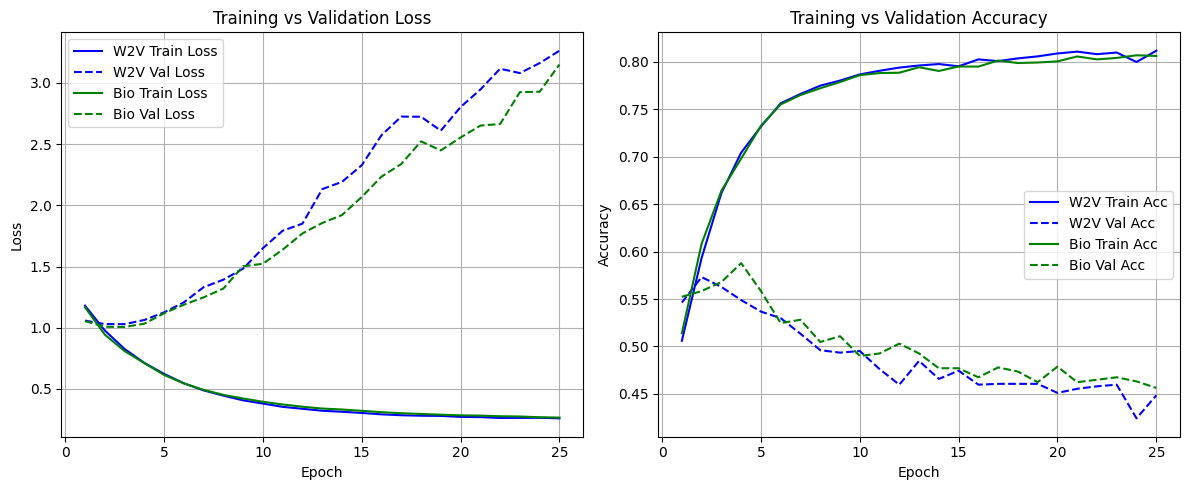

In [21]:
# Plot Training Process History
def plot_history(history_w2v, history_bio, epochs):
    # Extract training/validation loss and accuracy
    w2v_loss = history_w2v.history['loss']
    w2v_val_loss = history_w2v.history['val_loss']
    w2v_acc = history_w2v.history['accuracy']
    w2v_val_acc = history_w2v.history['val_accuracy']

    bio_loss = history_bio.history['loss']
    bio_val_loss = history_bio.history['val_loss']
    bio_acc = history_bio.history['accuracy']
    bio_val_acc = history_bio.history['val_accuracy']

    # ---------- Loss curve ----------
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(range(1, epochs+1), w2v_loss, label='W2V Train Loss', color='blue')
    plt.plot(range(1, epochs+1), w2v_val_loss, label='W2V Val Loss', color='blue', linestyle='--')
    plt.plot(range(1, epochs+1), bio_loss, label='Bio Train Loss', color='green')
    plt.plot(range(1, epochs+1), bio_val_loss, label='Bio Val Loss', color='green', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)

    # ---------- Accuracy curve ----------
    plt.subplot(1,2,2)
    plt.plot(range(1, epochs+1), w2v_acc, label='W2V Train Acc', color='blue')
    plt.plot(range(1, epochs+1), w2v_val_acc, label='W2V Val Acc', color='blue', linestyle='--')
    plt.plot(range(1, epochs+1), bio_acc, label='Bio Train Acc', color='green')
    plt.plot(range(1, epochs+1), bio_val_acc, label='Bio Val Acc', color='green', linestyle='--')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call the drawing function
plot_history(history_w2v, history_bio, epochs)

Interim Conclusions：

1.Under identical settings, BioWordVec's early best model significantly outperformed self-trained Word2Vec.

2.BioWordVec achieves greater precision in co-occurrence/synonym relationships learned from medical corpora such as PubMed/MIMIC, with higher sample efficiency.

3.The training loss of both models continued to decrease, while the validation loss began to rise starting from the 5th iteration. The validation accuracy first increased and then decreased, indicating significant overfitting.Early stopping combined with lightweight regularization should be adopted as the default training paradigm, with further optimization of both model and data based on this foundation.

# 6.Interactive Inference Colab Form
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [22]:
# Dropdown to choose which embedding-backed model to use
embed_choice = widgets.Dropdown(
    options=['-- Select model here --', 'Trained Embedding (Model1)', 'Pretrained Embedding (Model2)'],
    value='-- Select model here --',
    description='Embedding:'
)

# Test Sample Dropdown Menu
sample_options = [
    (f"Sample {i}: " + test_df['medical_abstract'].iloc[i][:50] + "...", i)
    for i in range(len(test_df))
]
sample_dropdown = widgets.Dropdown(
    options=sample_options,  # list of (display_text, index)
    value=0,                 # default to the first test sample
    description='Test Sample:'
)

# Textarea for custom input; if filled, it overrides the dropdown sample
custom_text = widgets.Textarea(
    value='',
    placeholder='Enter custom medical text here...',
    description='Custom Text:',
    layout=widgets.Layout(width='80%', height='100px')
)

# Predict button (duplicate assignment removed); optional background color via style
predict_button = widgets.Button(
    description="🏥 Predict 🩺",
    button_style='',  # or 'success'/'info'/'warning'/'danger'
    layout=widgets.Layout(width='150px', height='50px'),
    style={'button_color': '#CCFFCC'}
)

# Output area to capture and display prints
output_area = widgets.Output()

def on_predict_clicked(b):
    # Route all prints inside this context to the output area
    with output_area:
        output_area.clear_output()  # clear previous results

        # Guard: ensure a model is selected
        model_type = embed_choice.value
        if model_type == '-- Select model here --':
            print("⚠️ Please select a model before making a prediction!")
            return

        # Get input text and the ground-truth label
        if custom_text.value.strip():
            input_text   = custom_text.value.strip()
            actual_label = None
        else:
            idx          = sample_dropdown.value
            input_text   = test_df['medical_abstract'].iloc[idx]
            actual_label = test_df['condition_label'].iloc[idx]

        # Preprocess
        input_text_clean = clean_text(input_text)
        seq     = tokenizer.texts_to_sequences([input_text_clean])
        pad_seq = pad_sequences(seq, maxlen=max_len, padding='post')

        # Choose the model by dropdown
        if model_type.startswith('Trained'):
            pred_probs = model_w2v.predict(pad_seq)
        else:
            pred_probs = model_bio.predict(pad_seq)
        pred_label = pred_probs.argmax(axis=1)[0]

        # Map class id to human-readable label names
        label_names     = labels_df.sort_values('condition_label')['condition_name'].tolist()
        pred_label_name = label_names[pred_label]

        # Pretty print results
        print("-- Entered text --")
        print(input_text[:500] + ("..." if len(input_text) > 500 else ""))

        if actual_label is not None:
            true_label_name = label_names[actual_label - 1]
            print(f"\nActual Label: {true_label_name} (Label {actual_label})")
        else:
            print("\nActual Label: N/A (Custom input without actual labels)")

        # Show predicted label
        print(f"Predict Label: {pred_label_name} (Label {pred_label + 1})")

# Bind the click handler and display UI
predict_button.on_click(on_predict_clicked)
display(embed_choice, sample_dropdown, custom_text, predict_button, output_area)

Dropdown(description='Embedding:', options=('-- Select model here --', 'Trained Embedding (Model1)', 'Pretrain…

Dropdown(description='Test Sample:', options=(('Sample 0: Obstructive sleep apnea following topical orophary..…

Textarea(value='', description='Custom Text:', layout=Layout(height='100px', width='80%'), placeholder='Enter …

Button(description='🏥 Predict 🩺', layout=Layout(height='50px', width='150px'), style=ButtonStyle(button_color=…

Output()